HOW I CLEANED AND ANALYSED THE DATA

- First i studied the data 
- Mapping the missing values using other columns so i won't have to drop data
- Fixing the type and cleaning each column and row
- Recuing items by mapping it with the price column
- Handling transaction date 
- Business insight
- Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "iframe_connected"
import warnings 

warnings.filterwarnings
%matplotlib inline


In [2]:
df=pd.read_csv('project/dirty_cafe_sales.csv')
df_copy=df.copy()
df_copy.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
df_copy.info()  #information of data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [4]:
df_copy.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

Observation:

- Notice that the payment method, payment method, items and location have a of missing values in there respect 
columns, so the best way to tackle this issue is to use forward filling


In [5]:
df_copy['Payment Method'] = df_copy['Payment Method'].replace(['ERROR', 'UNKNOWN'], np.nan)
df_copy['Payment Method'] = df_copy['Payment Method'].fillna('Not Specified')

In [6]:
df_copy['Location'] = df_copy['Location'].replace(['ERROR', 'UNKNOWN'], np.nan)
df_copy['Location'] = df_copy['Location'].fillna('Not Specified')

In [7]:
df_copy['Location'].unique()

array(['Takeaway', 'In-store', 'Not Specified'], dtype=object)

In [8]:
df_copy.shape

(10000, 8)

In [9]:
df_copy['Day']=df_copy['Transaction Date'].str.split('-').str[2]
df_copy['Month']=df_copy['Transaction Date'].str.split('-').str[1]
df_copy['Year']=df_copy['Transaction Date'].str.split('-').str[0]

In [10]:
df_copy['Day'] = df_copy['Day'].ffill()
df_copy['Month'] = df_copy['Month'].ffill()
df_copy['Year'] = '2025'

In [11]:
df_copy['Year'].unique()

array(['2025'], dtype=object)

In [12]:
#drop transaction date 

df_copy.drop('Transaction Date', axis=1, inplace=True)

In [13]:
df_copy.isnull().sum()

Transaction ID      0
Item              333
Quantity          138
Price Per Unit    179
Total Spent       173
Payment Method      0
Location            0
Day                 0
Month               0
Year                0
dtype: int64

In [14]:
df_copy['Item'].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'UNKNOWN',
       'Sandwich', nan, 'ERROR', 'Juice', 'Tea'], dtype=object)

In [15]:
df_copy.shape

(10000, 10)

WE ARE SOLVING FOR THE MISSING NUMBERS TO MAPPING EACH COLUMN WITH ONE ANOTHER TO TRY AND RECOVER LOST DATA

Total Spent = Quantity x Price Per Unit

Quantity = Total Spent/ Price Per Unit

Price Per Unit = Total Spent/ Quantity

This code cleans and imputes missing values in a dataset containing transactional data with three key columns: Total Spent, Price Per Unit, and Quantity.

- Converting each column to numeric type (integers or floats) 
- I am performing the coversion so it prevents errors when performing mathematical operations
- errors='coerce' helps me make any non-numeric value (like strings, empty strings, or special characters) becomes NaN (Not a Number)

In [16]:
# Convert columns to numeric, coercing errors to NaN
df_copy['Total Spent'] = pd.to_numeric(df_copy['Total Spent'], errors='coerce')
df_copy['Price Per Unit'] = pd.to_numeric(df_copy['Price Per Unit'], errors='coerce')
df_copy['Quantity'] = pd.to_numeric(df_copy['Quantity'], errors='coerce')

# Now the division will work
quan1 = df_copy['Quantity'].isnull() & df_copy['Total Spent'].notnull() & df_copy['Price Per Unit'].notnull()
df_copy.loc[quan1, 'Quantity'] = df_copy.loc[quan1, 'Total Spent'] / df_copy.loc[quan1, 'Price Per Unit']

PPU = df_copy['Price Per Unit'].isnull() & df_copy['Total Spent'].notnull() & df_copy['Quantity'].notnull()
df_copy.loc[PPU, 'Price Per Unit'] = df_copy.loc[PPU, 'Total Spent'] / df_copy.loc[PPU, 'Quantity']

TS = df_copy['Total Spent'].isnull() & df_copy['Quantity'].notnull() & df_copy['Price Per Unit'].notnull()
df_copy.loc[TS, 'Total Spent'] = df_copy.loc[TS, 'Quantity'] * df_copy.loc[TS, 'Price Per Unit']

In [17]:
df_copy['Price Per Unit'].isnull().sum()  #checking for the NaN sum in the price per unit column 

np.int64(38)

In [18]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction ID  10000 non-null  object 
 1   Item            9667 non-null   object 
 2   Quantity        9962 non-null   float64
 3   Price Per Unit  9962 non-null   float64
 4   Total Spent     9960 non-null   float64
 5   Payment Method  10000 non-null  object 
 6   Location        10000 non-null  object 
 7   Day             10000 non-null  object 
 8   Month           10000 non-null  object 
 9   Year            10000 non-null  object 
dtypes: float64(3), object(7)
memory usage: 781.4+ KB


In [19]:
item_prices = df_copy.groupby('Item')['Price Per Unit'].median()
item_prices

Item
Cake        3.0
Coffee      2.0
Cookie      1.0
ERROR       3.0
Juice       3.0
Salad       5.0
Sandwich    4.0
Smoothie    4.0
Tea         1.5
UNKNOWN     3.0
Name: Price Per Unit, dtype: float64

In [20]:
df_copy['Price Per Unit'] = df_copy['Price Per Unit'].fillna(df_copy['Item'].map(item_prices))

In [21]:
df_copy['Price Per Unit'].unique()

array([2. , 3. , 1. , 5. , 4. , 1.5, nan])

handling the NaN values

- Filling missing values (NaNs) in three related columns of a DataFrame (df_copy): Total Spent, Quantity, and Price Per Unit.

In [22]:
df_copy['Total Spent'] = df_copy['Total Spent'].fillna(df_copy['Quantity'] * df_copy['Price Per Unit'])
df_copy['Quantity'] = df_copy['Quantity'].fillna(df_copy['Total Spent'] / df_copy['Price Per Unit'])
df_copy['Price Per Unit']= df_copy['Price Per Unit'].fillna(df_copy['Total Spent'] / df_copy['Quantity'])
df_copy.isnull().sum()

Transaction ID      0
Item              333
Quantity           21
Price Per Unit      2
Total Spent        21
Payment Method      0
Location            0
Day                 0
Month               0
Year                0
dtype: int64

In [23]:
df_copy['Item'].unique()  #checking the unique values of item

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'UNKNOWN',
       'Sandwich', nan, 'ERROR', 'Juice', 'Tea'], dtype=object)

In [24]:
df_copy.isnull().sum() #now we see that the  Quantity,Price Per Unit and Total spent have filled each other making us retrive lost data

Transaction ID      0
Item              333
Quantity           21
Price Per Unit      2
Total Spent        21
Payment Method      0
Location            0
Day                 0
Month               0
Year                0
dtype: int64

Handling Item Column

In [25]:
df_copy['Item'] = df_copy['Item'].replace(['ERROR', 'UNKNOWN'], np.nan) #coverting ERROR and UNKNOWN to NaN(not a number)

In [26]:
# Method 1: Priority dictionary for conflicting prices
price_to_item = {}

# First, add all non-null mappings
for idx, row in df_copy.dropna(subset=['Item']).iterrows():
    price_to_item[row['Price Per Unit']] = row['Item']

# Define priority items for specific prices (higher priority items override)
priority_items = {
    4: 'Sandwich',   # Override price 4 with Sandwich
    3: 'Cake',        # Override price 1 with Cake (instead of juice)

}

# Apply priority overrides
for price, item in priority_items.items():
    price_to_item[price] = item

# Fill NaN items
df_copy['Item'] = df_copy['Item'].fillna(df_copy['Price Per Unit'].map(price_to_item))

In [27]:
# Create mapping from existing non-null item-price pairs
price_to_item = df_copy.dropna(subset=['Item']).set_index('Price Per Unit')['Item'].to_dict()

# Then fill NaN items using price
df_copy['Item'] = df_copy['Item'].fillna(df_copy['Price Per Unit'].map(price_to_item))

Now dropping that NaN values in item,quantity and total spent because:

For Item: - had 2 columns i had to drop because one row had no item,quantity and price per unit but we have total spent making it had to recover data using just one information, the other only had quantity and that isn"t enough to recover the lost data

For Quantity & total Spent have the same missing value in each respective rows, so only price per unit is available which is not enough to recover data

In [28]:
df_copy = df_copy.dropna(subset=['Item'])
df_copy = df_copy.dropna(subset=['Quantity'])
df_copy = df_copy.dropna(subset=['Total Spent'])

After the data cleaning we only lost 22 records which is 0.22 percent of the data

In [29]:
df_copy.isnull().sum() #confirm that my data has no missing value

Transaction ID    0
Item              0
Quantity          0
Price Per Unit    0
Total Spent       0
Payment Method    0
Location          0
Day               0
Month             0
Year              0
dtype: int64

In [30]:
df_copy.shape #Total number of records and column

(9978, 10)

Saving both in csv file and excel

In [31]:
df_copy.to_csv('project/clean.csv')

In [32]:
df_copy.to_excel('excel_cleaned.xlsx', index=False, engine='openpyxl')

Finding out:
- Items and there revenue
- most bought item based on quantity
- most preferred location to eat to 
- Most payment method
- Highest sales per day & months

In [33]:
df_copy.groupby('Item')['Total Spent'].sum().reset_index()

,Item,Total Spent
0,Cake,12727.0
1,Coffee,7808.0
2,Cookie,3598.0
3,Juice,10515.0
4,Salad,19095.0
5,Sandwich,16532.0
6,Smoothie,13344.0
7,Tea,5475.0


The most bought item

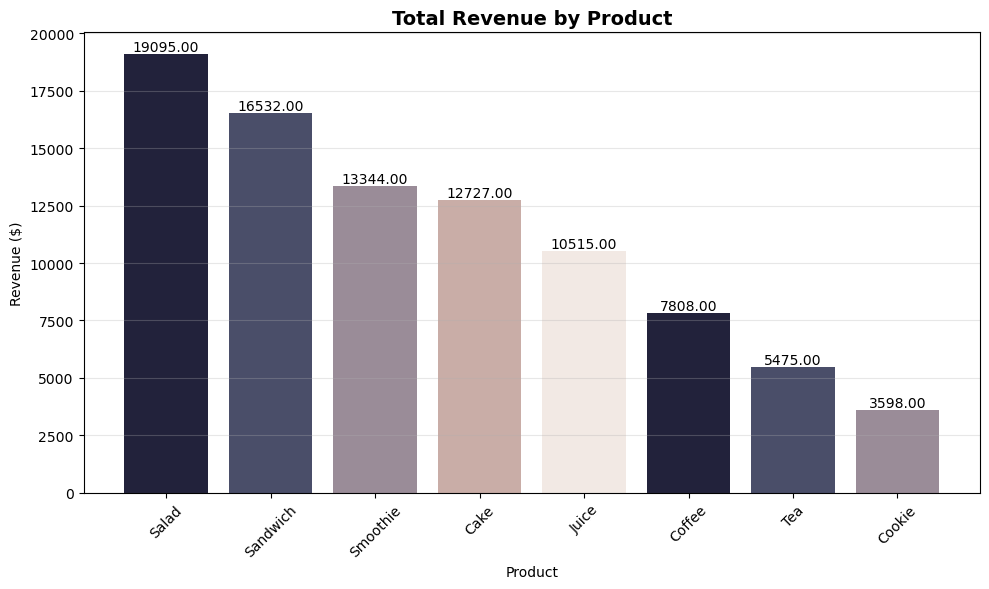

In [34]:
# Calculate the same data
item_sales = df_copy.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#22223B", "#4A4E69", "#9A8C98", "#C9ADA7", "#F2E9E4"]
bars = ax.bar(item_sales.index, item_sales.values, color=colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', rotation=0)

# Customize
ax.set_title('Total Revenue by Product', fontsize=14, fontweight='bold')
ax.set_xlabel('Product')
ax.set_ylabel('Revenue ($)')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Observation for the most bought item:

- Salad is the most paid for in total 
- the least paid for is Tea


Finding the most bought item

In [35]:
df_copy.groupby('Item')['Quantity'].sum().reset_index()

,Item,Quantity
0,Cake,4242.333333
1,Coffee,3904.000000
2,Cookie,3598.000000
3,Juice,3505.000000
4,Salad,3819.000000
5,Sandwich,4133.000000
6,Smoothie,3336.000000
7,Tea,3650.000000


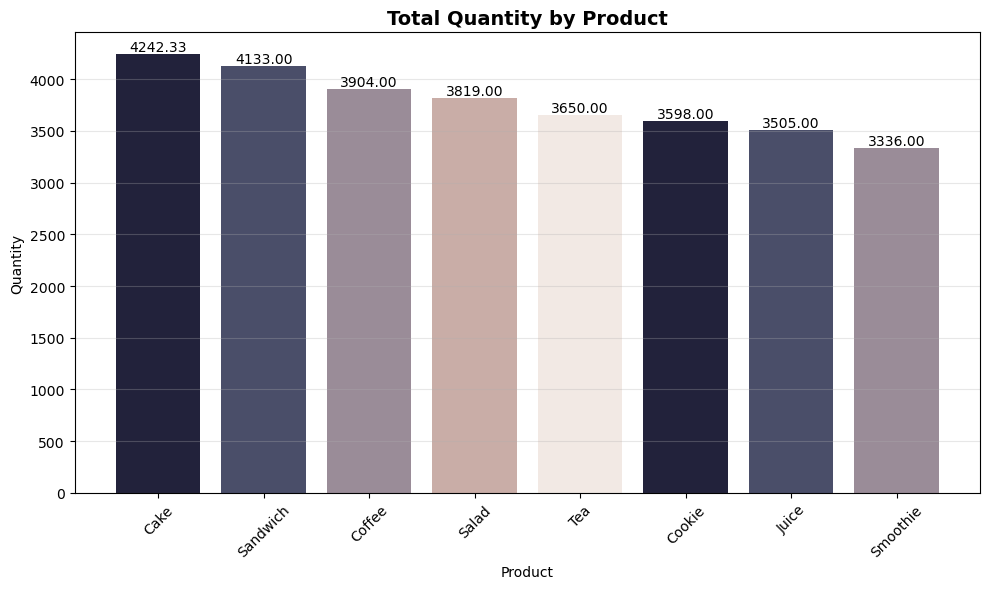

In [36]:
# Calculate the same data
item_sales = df_copy.groupby('Item')['Quantity'].sum().sort_values(ascending=False)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#22223B", "#4A4E69", "#9A8C98", "#C9ADA7", "#F2E9E4"]
bars = ax.bar(item_sales.index, item_sales.values, color=colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', rotation=0)

# Customize
ax.set_title('Total Quantity by Product', fontsize=14, fontweight='bold')
ax.set_xlabel('Product')
ax.set_ylabel('Quantity')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Now we see that the item with the most quantity is cake but it is not the item with the highest total spent on because it has lower price per unit than salad

The most preffered location to consume bought items


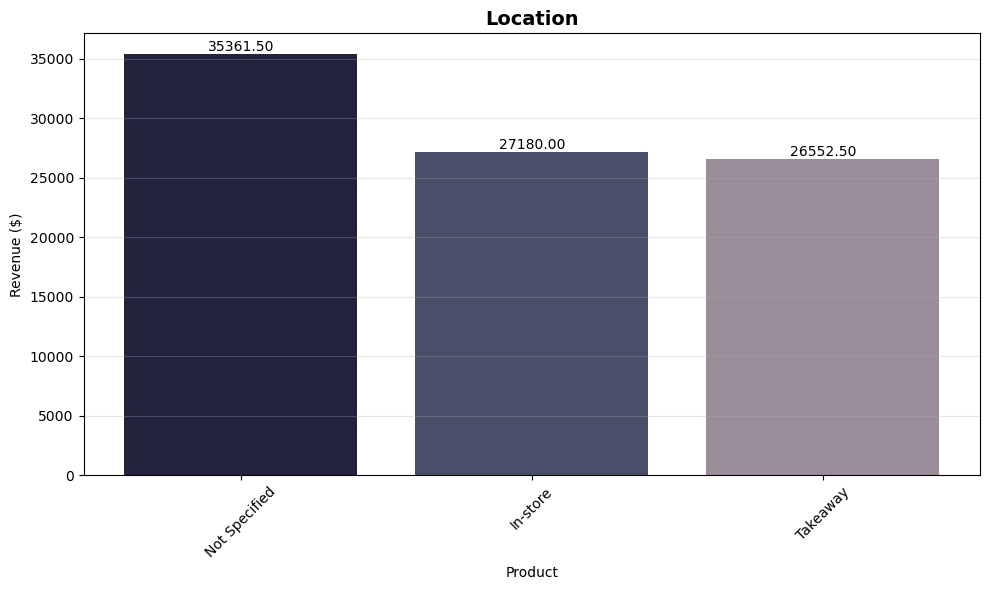

In [37]:
# Calculate the same data
item_sales = df_copy.groupby('Location')['Total Spent'].sum().sort_values(ascending=False)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#22223B", "#4A4E69", "#9A8C98", "#C9ADA7", "#F2E9E4"]
bars = ax.bar(item_sales.index, item_sales.values, color=colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', rotation=0)

# Customize
ax.set_title('Location', fontsize=14, fontweight='bold')
ax.set_xlabel('Product')
ax.set_ylabel('Revenue ($)')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

I observed that both location are almost equal but the missing data makes it hard to know which of the locations consumers preffer to eat at

Most used Payment Method

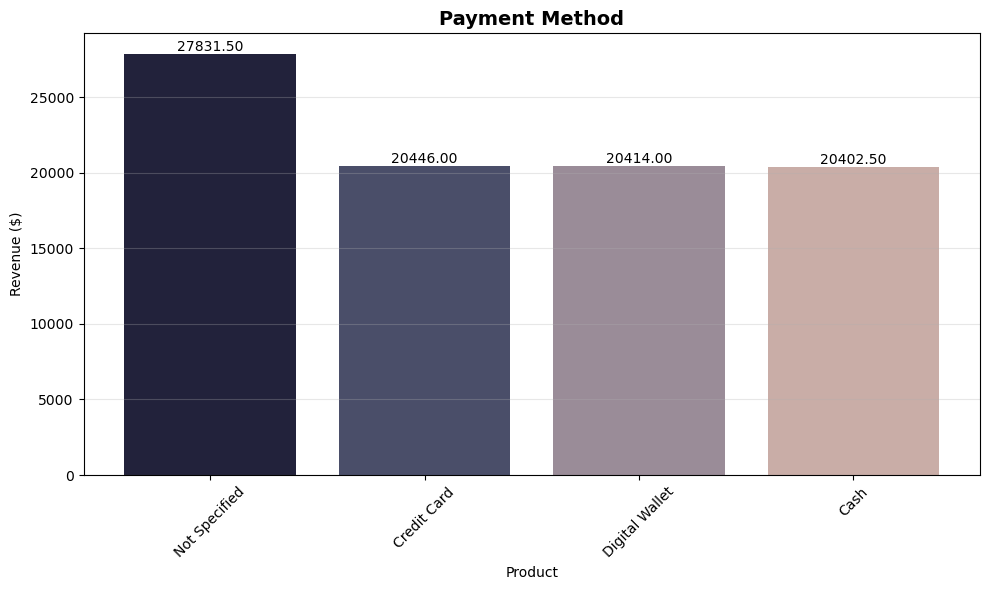

In [38]:
# Calculate the same data
item_sales = df_copy.groupby('Payment Method')['Total Spent'].sum().sort_values(ascending=False)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#22223B", "#4A4E69", "#9A8C98", "#C9ADA7", "#F2E9E4"]
bars = ax.bar(item_sales.index, item_sales.values, color=colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', rotation=0)

# Customize
ax.set_title('Payment Method', fontsize=14, fontweight='bold')
ax.set_xlabel('Product')
ax.set_ylabel('Revenue ($)')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

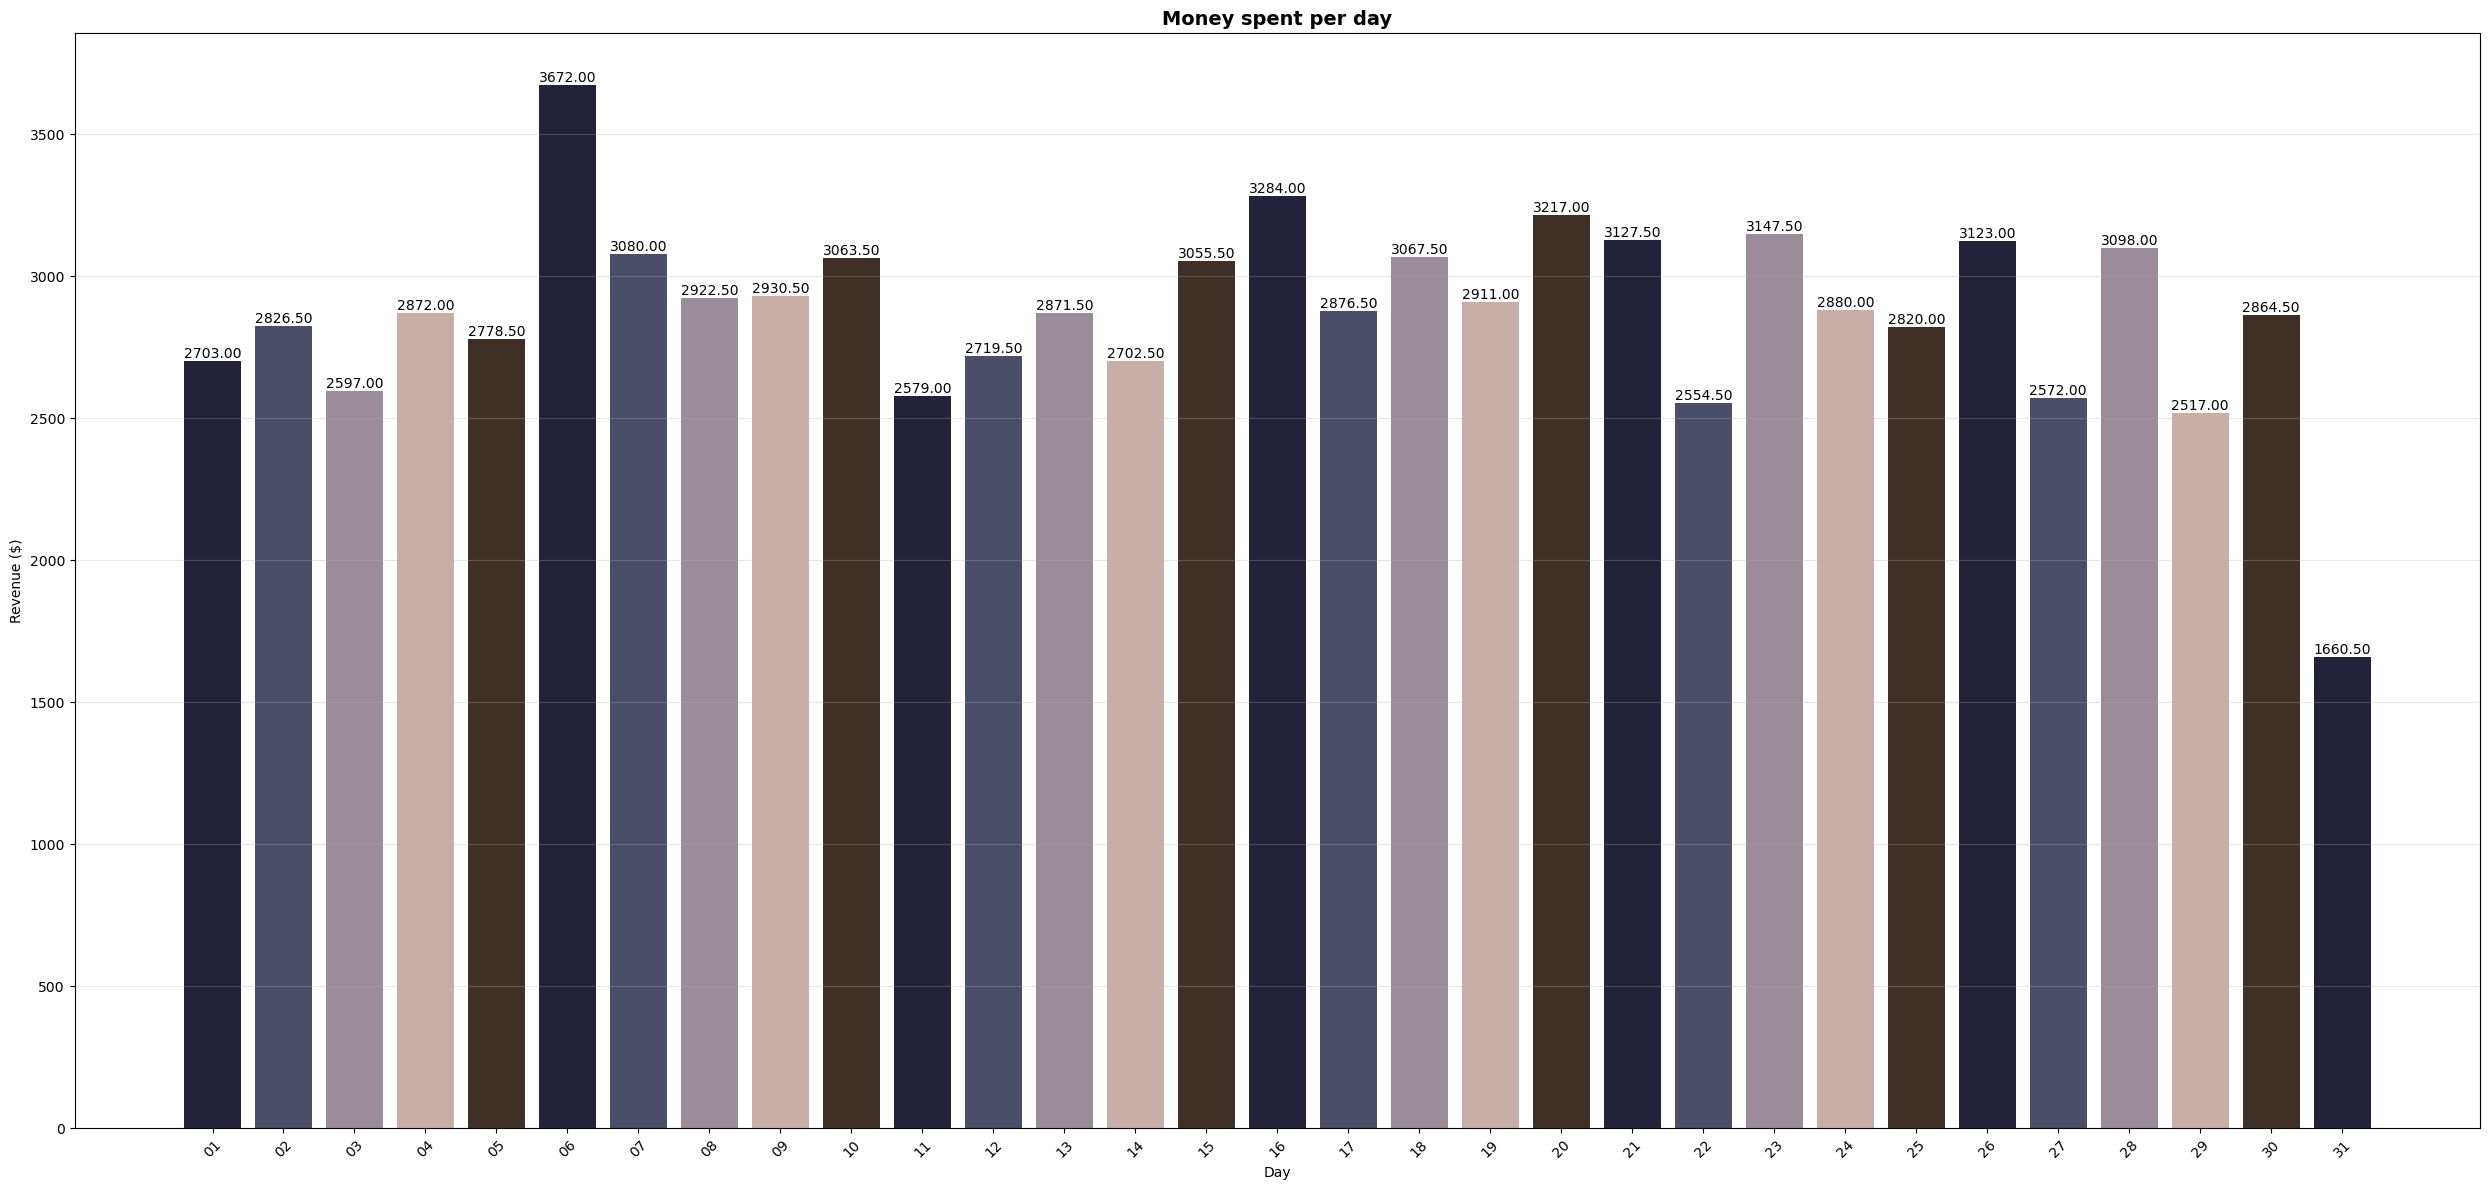

In [39]:
# Calculate the same data - sort by day instead of by revenue
item_sales = df_copy.groupby('Day')['Total Spent'].sum().sort_index()  # Changed from sort_values to sort_index

# Create the plot
fig, ax = plt.subplots(figsize=(25, 12))
colors = ["#22223B", "#4A4E69", "#9A8C98", "#C9ADA7", "#3F3027"]
bars = ax.bar(item_sales.index, item_sales.values, color=colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', rotation=0)

# Customize
ax.set_title('Money spent per day', fontsize=14, fontweight='bold')
ax.set_xlabel('Day')  # Changed from 'Product' to 'Day' (more accurate)
ax.set_ylabel('Revenue ($)')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

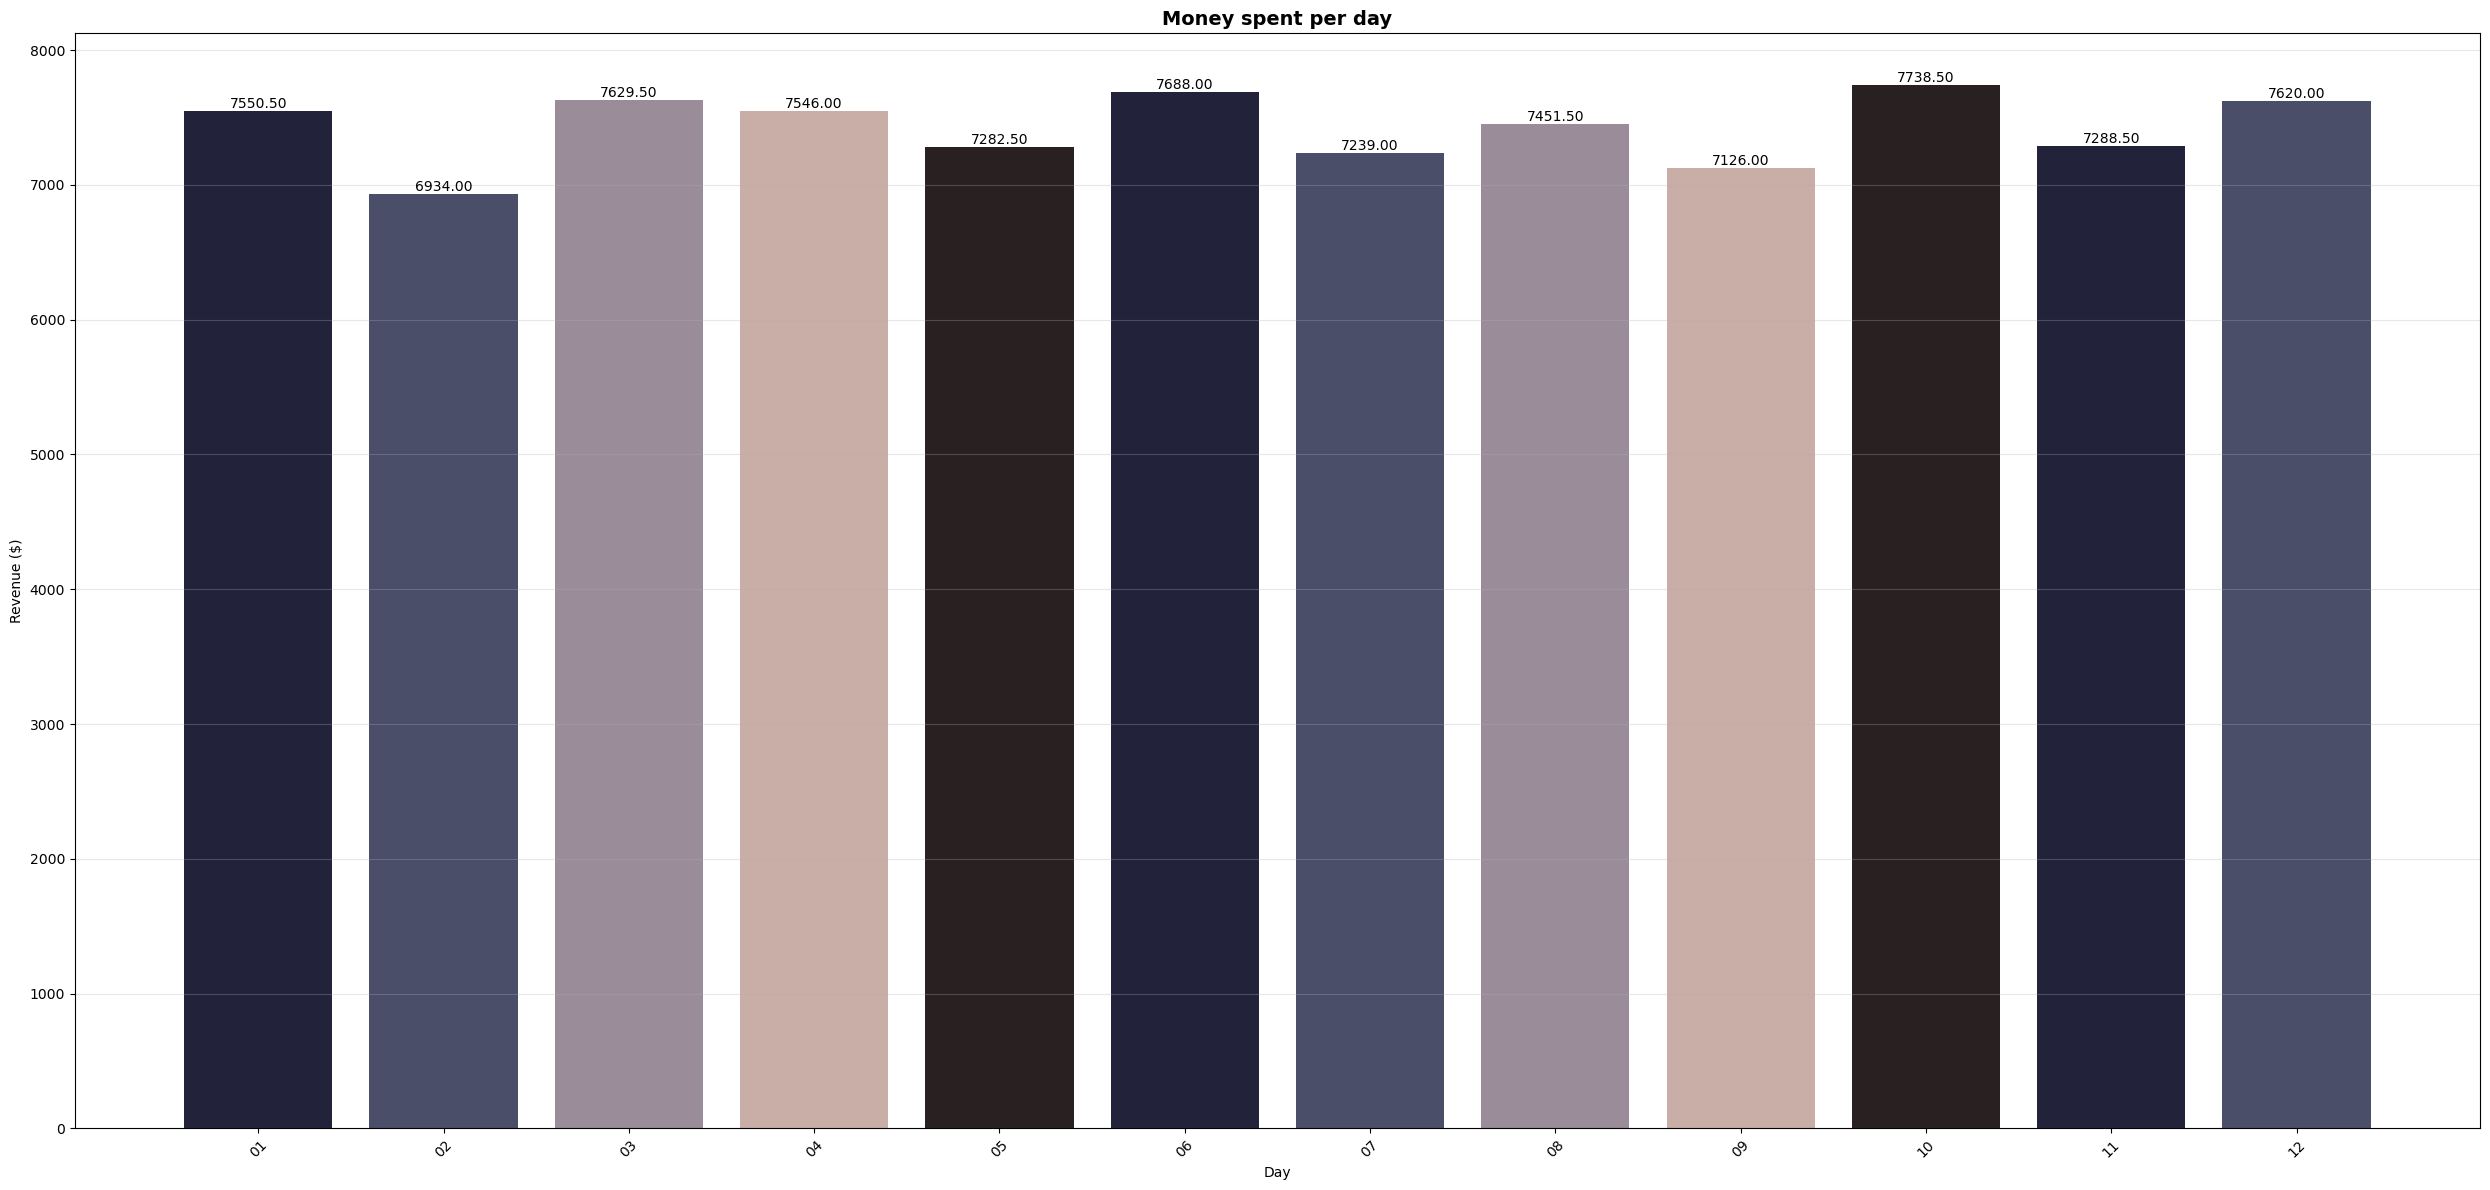

In [40]:
# Calculate the same data - sort by day instead of by revenue
item_sales = df_copy.groupby('Month')['Total Spent'].sum().sort_index()  # Changed from sort_values to sort_index

# Create the plot
fig, ax = plt.subplots(figsize=(25, 12))
colors = ["#22223B", "#4A4E69", "#9A8C98", "#C9ADA7", "#292121"]
bars = ax.bar(item_sales.index, item_sales.values, color=colors)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', rotation=0)

# Customize
ax.set_title('Money spent per day', fontsize=14, fontweight='bold')
ax.set_xlabel('Day')  # Changed from 'Product' to 'Day' (more accurate)
ax.set_ylabel('Revenue ($)')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
df_copy.head(10)

KEY BUSINESS IN SIGHT

- The top item that generates the most revenue is Salad being the most expensive but not the most bought
- The top item bought/ordered the most is Cake and it doesn't top Salad 
- Both location are almost equally the same 
- The not specified in payment method has over $27831.50 missing in records 
- Trend is 7426/month


RECCOMENDATION BASED ON MY ANALYSIS 

- Fix payment method to have a cleaner and neater payment records to track profit, loss, progress and theft
- Salad is having higher  revenue and giving the advice to try more salad combo
- The cookies have a good order record but barely generates strong revenue and i know bringing more cookie varieties and adding more price to it will give a good progress in that aspect
- sales at cafe are great and stable having no high peak month
- Since both location are almost equal, investing in both will bring in more people